# Metal Visualization — Group-Stratified Correlation Analysis
## How Programming Experience Changes the Relationship Between Eye-Tracking Variables

---

**Core question:** Do the correlations between attention metrics *change* with programming experience? A correlation that is strong for experts but absent for novices indicates that expertise reorganizes the attentional system — not just the level of a metric, but the relationship between metrics.

**Method:** Fisher's z-transformation is used to test whether Spearman correlation coefficients computed in different groups are significantly different from each other. This directly tests whether experience *moderates* the relationship between two variables.

**Groups:**
- **G1** — No programming experience (n=38: 19 BFS, 19 DFS)
- **G2** — Brief knowledge of programming (n=39: 20 BFS, 19 DFS)
- **G3** — Multiple years of programming coursework (n=40: 20 BFS, 20 DFS)

---
## 1. Setup & Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from itertools import combinations
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('../')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

ALG_PAL   = {'BFS': '#2166AC', 'DFS': '#D6604D'}
GRP_COL   = {1: '#1B7837', 2: '#762A83', 3: '#E66101'}
GRP_COL_S = {'1': '#1B7837', '2': '#762A83', '3': '#E66101'}
GRP_LBL   = {1: 'G1 (no exp)', 2: 'G2 (brief)', 3: 'G3 (years)'}
print('Setup complete.')

Setup complete.


In [2]:
METAL_FILES = [
    ('Group1_metalBFSData.xls', 'BFS', 'DE-bft.wmv', 1),
    ('Group1_metalDFSData.xls', 'DFS', 'DE-dft.wmv', 1),
    ('Group2_metalBFSData.xls', 'BFS', 'DE-bft.wmv', 2),
    ('Group2_metalDFSData.xls', 'DFS', 'DE-dft.wmv', 2),
    ('Group3_metalBFSData.xls', 'BFS', 'DE-bft.wmv', 3),
    ('Group3_metalDFSData.xls', 'DFS', 'DE-dft.wmv', 3),
]
STAT_KW = {'nan','mean','sum','std','median','','all recordings'}

def get_col(df, metric, video, aoi):
    return next((c for c in df.columns if metric in c and video in c and aoi in c
                 and c.endswith('_Mean') and 'Include Zeros' not in c), None)

records = []
for fname, algo, video, grp in METAL_FILES:
    df_raw = pd.read_excel(DATA_DIR / fname, engine='xlrd')
    df_raw = df_raw.rename(columns={df_raw.columns[0]: 'participant'})
    col = {
        'tfd_pseudo':  get_col(df_raw, 'Total Fixation Duration',  video, 'Rectangle_'),
        'tfd_map':     get_col(df_raw, 'Total Fixation Duration',  video, 'Rectangle 2_'),
        'fc_pseudo':   get_col(df_raw, 'Fixation Count',           video, 'Rectangle_'),
        'fc_map':      get_col(df_raw, 'Fixation Count',           video, 'Rectangle 2_'),
        'ttff_pseudo': get_col(df_raw, 'Time to First Fixation',   video, 'Rectangle_'),
        'ttff_map':    get_col(df_raw, 'Time to First Fixation',   video, 'Rectangle 2_'),
        'fix_before':  get_col(df_raw, 'Fixations Before',         video, 'Rectangle_'),
        'vc_pseudo':   get_col(df_raw, 'Visit Count',              video, 'Rectangle_'),
        'vc_map':      get_col(df_raw, 'Visit Count',              video, 'Rectangle 2_'),
        'ffd_pseudo':  get_col(df_raw, 'First Fixation Duration',  video, 'Rectangle_'),
        'pct_pseudo':  get_col(df_raw, 'Percentage Fixated',       video, 'Rectangle_'),
        'pct_map':     get_col(df_raw, 'Percentage Fixated',       video, 'Rectangle 2_'),
    }
    for _, row in df_raw.iterrows():
        pname = str(row.iloc[0]).strip()
        if pname.lower() in STAT_KW: continue
        pid = pname.split('-')[0].split('=')[0].strip()
        records.append({'participant': pid, 'algorithm': algo, 'group': grp,
            **{k: pd.to_numeric(row.get(v), errors='coerce') if v else np.nan
               for k, v in col.items()}})

df = pd.DataFrame(records)
df['ratio']          = df['tfd_pseudo'] / (df['tfd_map']    + 1e-9)
df['scanner_index']  = df['vc_pseudo']  / (df['tfd_pseudo'] + 1e-9)
df['avg_fix_depth']  = df['tfd_pseudo'] / (df['fc_pseudo']  + 1e-9)
df['switching_rate'] = (df['vc_pseudo'] + df['vc_map']) / (df['tfd_pseudo'] + df['tfd_map'] + 1e-9)
df['map_first']      = (df['ttff_map'] < df['ttff_pseudo']).astype(float)
# Clip ratio outliers
df['ratio_c']        = df['ratio'].where(df['ratio'] < 25)

print(df.groupby(['group','algorithm']).size().unstack())
print(f'\nTotal: {len(df)}')

algorithm  BFS  DFS
group              
1           19   19
2           20   19
3           20   20

Total: 117


---
## 2. Fisher's Z-Test Battery

For every pair of metrics, compute Spearman r within each group (collapsed across BFS/DFS), then test whether r differs significantly between groups using the Fisher z-transformation.

$$z = \frac{\text{arctanh}(r_1) - \text{arctanh}(r_2)}{\sqrt{\frac{1}{n_1 - 3} + \frac{1}{n_2 - 3}}}$$

A significant Fisher z-test means the *relationship* between two variables changed with experience — not just the level of a variable, but how two variables co-vary.

In [3]:
def fisher_z_diff(r1, n1, r2, n2):
    """Two-tailed Fisher z-test for the difference between two Spearman correlations."""
    r1 = np.clip(r1, -0.9999, 0.9999)
    r2 = np.clip(r2, -0.9999, 0.9999)
    z1, z2 = np.arctanh(r1), np.arctanh(r2)
    se = np.sqrt(1 / (n1 - 3) + 1 / (n2 - 3))
    z_stat = (z1 - z2) / se
    p = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    return z_stat, p


def grp_spearman(data, x_col, y_col, grp):
    sub = data[data['group'] == grp]
    x = sub[x_col].replace([np.inf, -np.inf], np.nan)
    y = sub[y_col].replace([np.inf, -np.inf], np.nan)
    valid = x.notna() & y.notna()
    if valid.sum() < 5:
        return np.nan, np.nan, valid.sum()
    r, p = stats.spearmanr(x[valid], y[valid])
    return r, p, int(valid.sum())


print('Utilities defined.')

Utilities defined.


In [4]:
METRICS = [
    'ratio_c', 'scanner_index', 'avg_fix_depth', 'switching_rate',
    'fix_before', 'ttff_pseudo', 'ttff_map', 'ffd_pseudo',
    'tfd_pseudo', 'tfd_map', 'fc_pseudo', 'fc_map',
    'vc_pseudo', 'vc_map', 'map_first'
]

battery = []
for x_col, y_col in combinations(METRICS, 2):
    r1, _, n1 = grp_spearman(df, x_col, y_col, 1)
    r2, _, n2 = grp_spearman(df, x_col, y_col, 2)
    r3, _, n3 = grp_spearman(df, x_col, y_col, 3)
    if any(np.isnan(v) for v in [r1, r2, r3]):
        continue
    _, p12 = fisher_z_diff(r1, n1, r2, n2)
    _, p13 = fisher_z_diff(r1, n1, r3, n3)
    _, p23 = fisher_z_diff(r2, n2, r3, n3)
    battery.append({
        'x': x_col, 'y': y_col,
        'r_G1': round(r1, 3), 'r_G2': round(r2, 3), 'r_G3': round(r3, 3),
        'p_G1G2': round(p12, 4), 'p_G1G3': round(p13, 4), 'p_G2G3': round(p23, 4),
        'max_r_diff': round(max(abs(r1-r2), abs(r1-r3), abs(r2-r3)), 3),
        'min_p': round(min(p12, p13, p23), 4),
        'direction_change': (r1 * r3 < 0),   # True if correlation reverses sign between G1 and G3
    })

bat = pd.DataFrame(battery)

def sig(p):
    return '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else '~' if p<.10 else 'ns'

bat['sig_12'] = bat['p_G1G2'].apply(sig)
bat['sig_13'] = bat['p_G1G3'].apply(sig)
bat['sig_23'] = bat['p_G2G3'].apply(sig)

print(f'Total metric pairs tested: {len(bat)}')
print(f'Pairs with any significant group difference (p<.05): {(bat["min_p"]<.05).sum()}')
print(f'Direction reversals between G1 and G3: {bat["direction_change"].sum()}')
print()
print('=== Top 25 pairs sorted by strength of group moderation (min_p) ===')
cols = ['x','y','r_G1','r_G2','r_G3','p_G1G2','p_G1G3','p_G2G3','max_r_diff','direction_change']
print(bat.sort_values('min_p').head(25)[cols].to_string(index=False))

Total metric pairs tested: 105
Pairs with any significant group difference (p<.05): 27
Direction reversals between G1 and G3: 25

=== Top 25 pairs sorted by strength of group moderation (min_p) ===
             x              y   r_G1   r_G2   r_G3  p_G1G2  p_G1G3  p_G2G3  max_r_diff  direction_change
 scanner_index      vc_pseudo  0.880  0.954  0.732  0.0363  0.0631  0.0001       0.222             False
switching_rate      vc_pseudo  0.828  0.935  0.714  0.0313  0.2289  0.0006       0.221             False
       ratio_c  scanner_index -0.037 -0.313 -0.674  0.2592  0.0021  0.0446       0.637             False
 scanner_index        tfd_map  0.071  0.303  0.656  0.3118  0.0026  0.0436       0.585             False
    tfd_pseudo      fc_pseudo  0.163 -0.168  0.488  0.1619  0.1204  0.0027       0.656             False
       ratio_c      fc_pseudo -0.018 -0.256  0.401  0.3392  0.0818  0.0053       0.657              True
 scanner_index         fc_map  0.191  0.373  0.689  0.4052  0.0060 

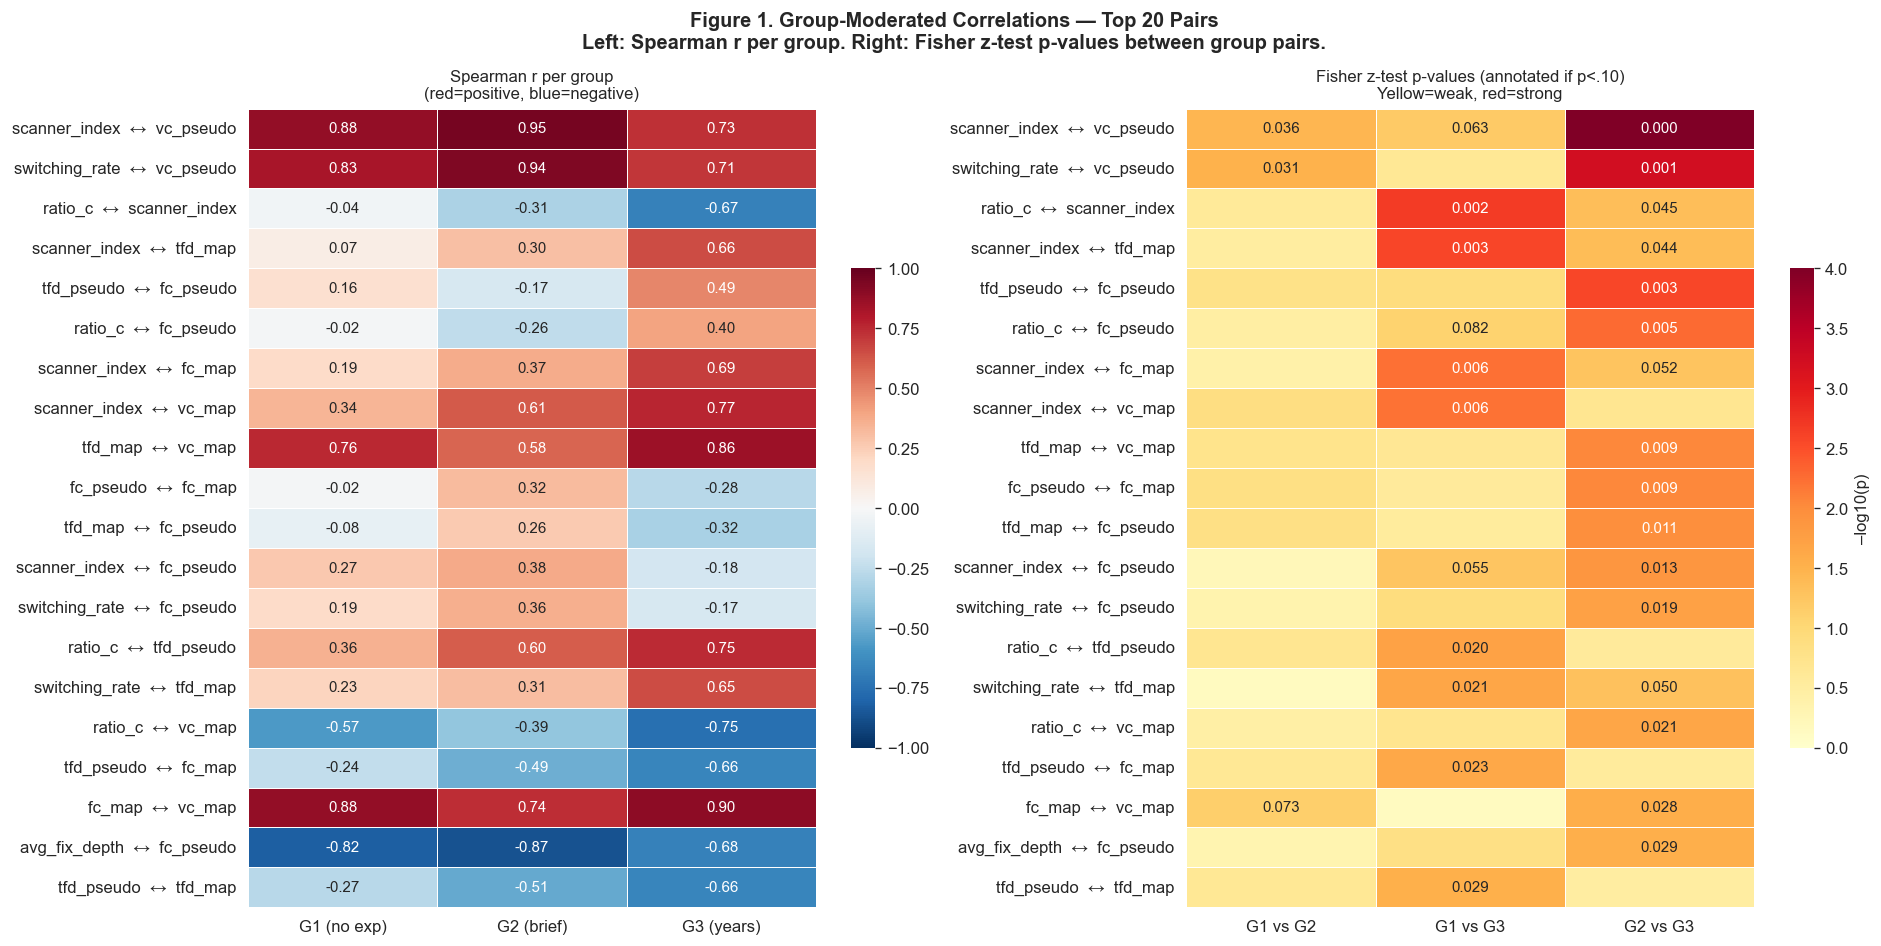

In [5]:
# Figure 1 — Heatmap of r values for top pairs, grouped by which comparison is significant
# Show the top 20 most-moderated pairs; rows = pair, columns = G1/G2/G3

top20 = bat.sort_values('min_p').head(20).copy()
top20['pair'] = top20.apply(lambda r: f"{r['x']}  ↔  {r['y']}", axis=1)

r_matrix = top20[['pair','r_G1','r_G2','r_G3']].set_index('pair')
p_matrix = top20[['pair','p_G1G2','p_G1G3','p_G2G3']].set_index('pair')

fig, axes = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'width_ratios': [3, 3]})
fig.suptitle(
    'Figure 1. Group-Moderated Correlations — Top 20 Pairs\n'
    'Left: Spearman r per group. Right: Fisher z-test p-values between group pairs.',
    fontsize=12, fontweight='bold'
)

# Left: r values per group
sns.heatmap(
    r_matrix, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=axes[0], cbar_kws={'shrink': 0.6},
    annot_kws={'size': 9}
)
axes[0].set_title('Spearman r per group\n(red=positive, blue=negative)', fontsize=10)
axes[0].set_xticklabels(['G1 (no exp)', 'G2 (brief)', 'G3 (years)'], rotation=0)
axes[0].set_ylabel('')

# Right: –log10(p) for each comparison
log_p = p_matrix.apply(lambda col: -np.log10(col.clip(lower=1e-10)))
log_p.columns = ['G1 vs G2', 'G1 vs G3', 'G2 vs G3']
annot_p = p_matrix.copy()
annot_p.columns = ['G1 vs G2', 'G1 vs G3', 'G2 vs G3']
annot_p = annot_p.map(lambda v: f'{v:.3f}' if v < 0.10 else '')

sns.heatmap(
    log_p, annot=annot_p, fmt='',
    cmap='YlOrRd', vmin=0, vmax=4,
    linewidths=0.4, ax=axes[1], cbar_kws={'shrink': 0.6, 'label': '–log10(p)'},
    annot_kws={'size': 9}
)
axes[1].set_title('Fisher z-test p-values (annotated if p<.10)\nYellow=weak, red=strong', fontsize=10)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('fig1_fisher_battery.png', bbox_inches='tight')
plt.show()

---
## 3. Correlation Structure Change Map

Computing the full Spearman correlation matrix for each group, then the *difference* G3 – G1. Each cell in the difference matrix is the change in correlation coefficient from novice to expert. Large positive values mean a relationship grew stronger with expertise; large negative values mean it dissolved or reversed.

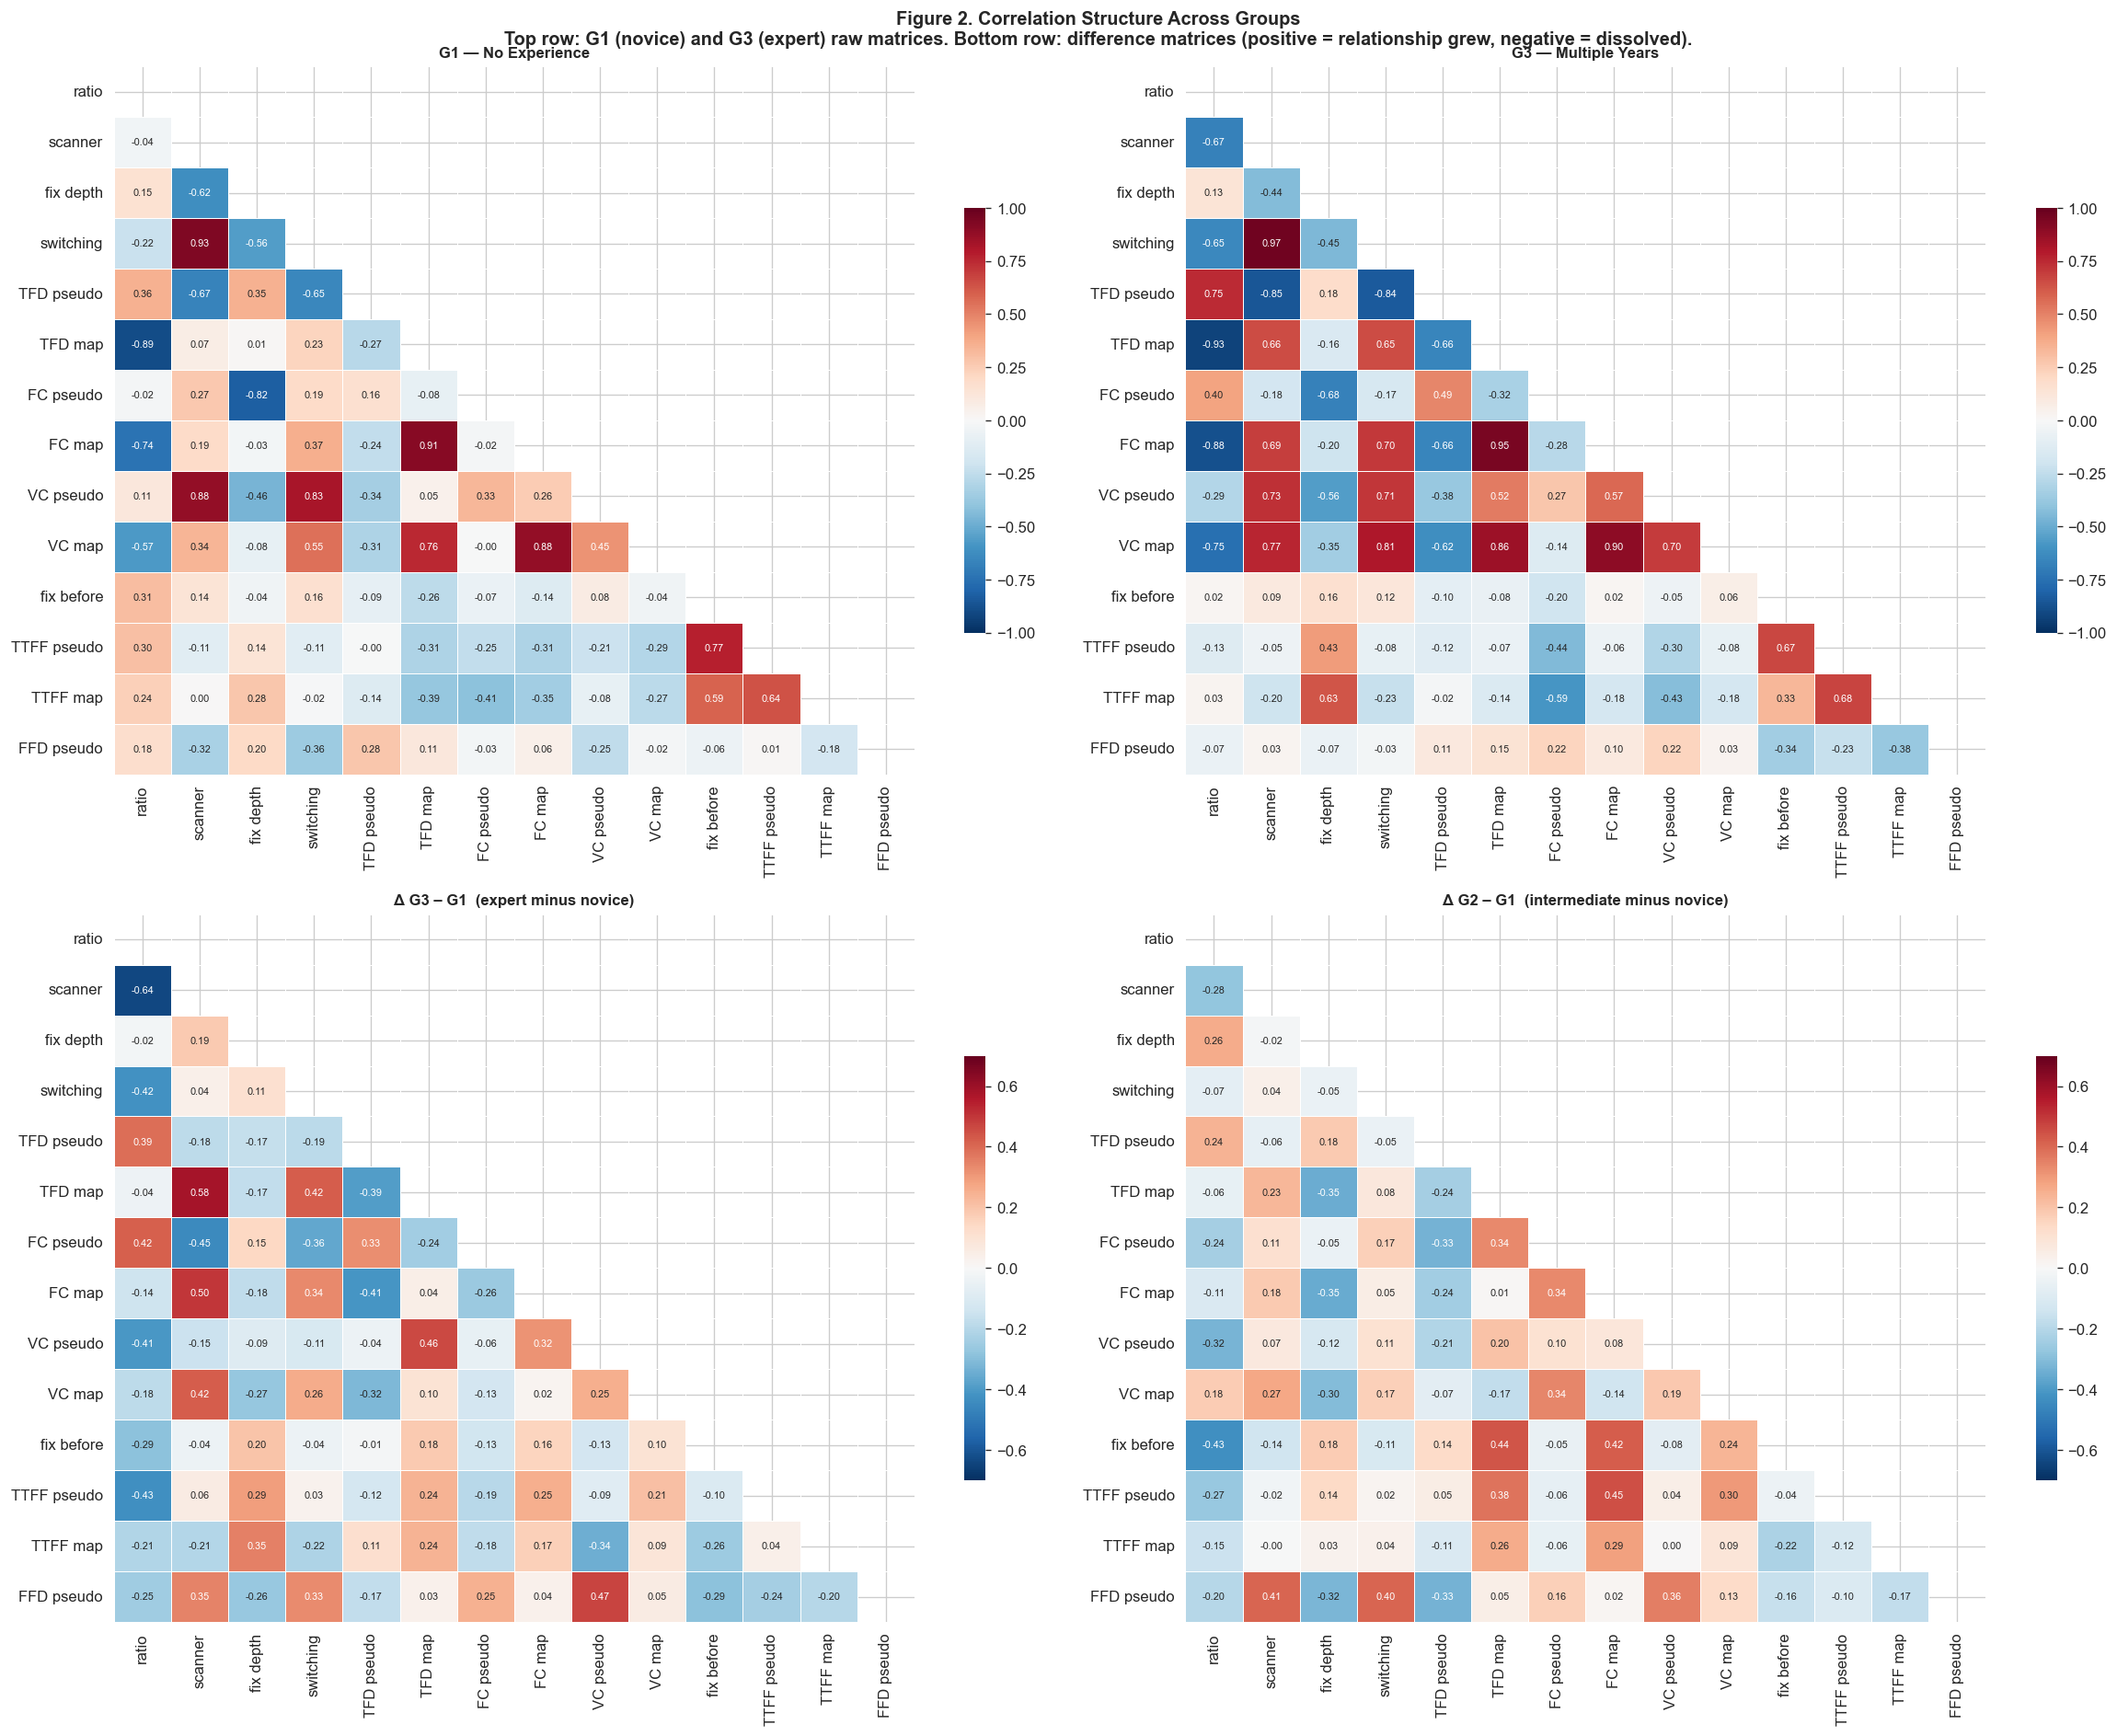

In [6]:
DISPLAY_METRICS = [
    'ratio_c', 'scanner_index', 'avg_fix_depth', 'switching_rate',
    'tfd_pseudo', 'tfd_map', 'fc_pseudo', 'fc_map',
    'vc_pseudo', 'vc_map', 'fix_before', 'ttff_pseudo', 'ttff_map', 'ffd_pseudo'
]
DISPLAY_LBL = [
    'ratio', 'scanner', 'fix depth', 'switching',
    'TFD pseudo', 'TFD map', 'FC pseudo', 'FC map',
    'VC pseudo', 'VC map', 'fix before', 'TTFF pseudo', 'TTFF map', 'FFD pseudo'
]

def corr_matrix(data, metrics, labels):
    sub = data[metrics].replace([np.inf,-np.inf], np.nan)
    m = sub.corr(method='spearman')
    m.index = labels; m.columns = labels
    return m

corr_G1 = corr_matrix(df[df['group']==1], DISPLAY_METRICS, DISPLAY_LBL)
corr_G2 = corr_matrix(df[df['group']==2], DISPLAY_METRICS, DISPLAY_LBL)
corr_G3 = corr_matrix(df[df['group']==3], DISPLAY_METRICS, DISPLAY_LBL)

delta_G3_G1 = corr_G3 - corr_G1   # positive = correlation grew with expertise
delta_G2_G1 = corr_G2 - corr_G1   # G2 vs G1
delta_G3_G2 = corr_G3 - corr_G2   # G3 vs G2

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle(
    'Figure 2. Correlation Structure Across Groups\n'
    'Top row: G1 (novice) and G3 (expert) raw matrices. '
    'Bottom row: difference matrices (positive = relationship grew, negative = dissolved).',
    fontsize=12, fontweight='bold'
)

mask = np.triu(np.ones(corr_G1.shape, dtype=bool))

for ax, mat, title in [
    (axes[0][0], corr_G1, 'G1 — No Experience'),
    (axes[0][1], corr_G3, 'G3 — Multiple Years'),
    (axes[1][0], delta_G3_G1, 'Δ G3 – G1  (expert minus novice)'),
    (axes[1][1], delta_G2_G1, 'Δ G2 – G1  (intermediate minus novice)'),
]:
    vext = 1.0 if 'Δ' not in title else 0.7
    sns.heatmap(
        mat, mask=mask, annot=True, fmt='.2f',
        cmap='RdBu_r', center=0, vmin=-vext, vmax=vext,
        linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.6},
        annot_kws={'size': 6.5}
    )
    ax.set_title(title, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_corr_structure_change.png', bbox_inches='tight')
plt.show()

In [7]:
# Extract the largest shifts from G1 → G3
delta_vals = []
for i, r in enumerate(DISPLAY_LBL):
    for j, c in enumerate(DISPLAY_LBL):
        if j >= i: continue
        delta_vals.append({
            'var1': r, 'var2': c,
            'r_G1': round(corr_G1.iloc[i,j], 3),
            'r_G2': round(corr_G2.iloc[i,j], 3),
            'r_G3': round(corr_G3.iloc[i,j], 3),
            'delta_G3_G1': round(delta_G3_G1.iloc[i,j], 3),
        })

delta_df = pd.DataFrame(delta_vals)
delta_df['abs_delta'] = delta_df['delta_G3_G1'].abs()
delta_df = delta_df.sort_values('abs_delta', ascending=False)

print('=== Largest correlation shifts from G1 (novice) → G3 (expert) ===')
print('Positive delta = relationship grew; negative = dissolved or reversed')
print()
print(delta_df.head(20)[['var1','var2','r_G1','r_G2','r_G3','delta_G3_G1']].to_string(index=False))

=== Largest correlation shifts from G1 (novice) → G3 (expert) ===
Positive delta = relationship grew; negative = dissolved or reversed

       var1       var2   r_G1   r_G2   r_G3  delta_G3_G1
    scanner      ratio -0.037 -0.313 -0.674       -0.637
    TFD map    scanner  0.071  0.303  0.656        0.585
     FC map    scanner  0.191  0.373  0.689        0.498
 FFD pseudo  VC pseudo -0.251  0.106  0.220        0.471
  VC pseudo    TFD map  0.054  0.259  0.516        0.461
  FC pseudo    scanner  0.266  0.379 -0.181       -0.447
TTFF pseudo      ratio  0.298  0.033 -0.132       -0.431
    TFD map  switching  0.226  0.307  0.651        0.424
  switching      ratio -0.223 -0.294 -0.647       -0.423
     VC map    scanner  0.343  0.614  0.765        0.422
  FC pseudo      ratio -0.018 -0.256  0.401        0.419
     FC map TFD pseudo -0.244 -0.489 -0.658       -0.414
  VC pseudo      ratio  0.112 -0.211 -0.293       -0.405
 TFD pseudo      ratio  0.359  0.602  0.749        0.390
    TFD m

---
## 4. Five Key Moderation Relationships — Scatter Plots with Per-Group Regression Lines

For the five pairs with the most dramatic group-dependent correlations, we plot all participants with per-group regression lines. This makes the moderation visible: a diverging fan pattern means the groups have different slopes; crossing lines mean a direction reversal.

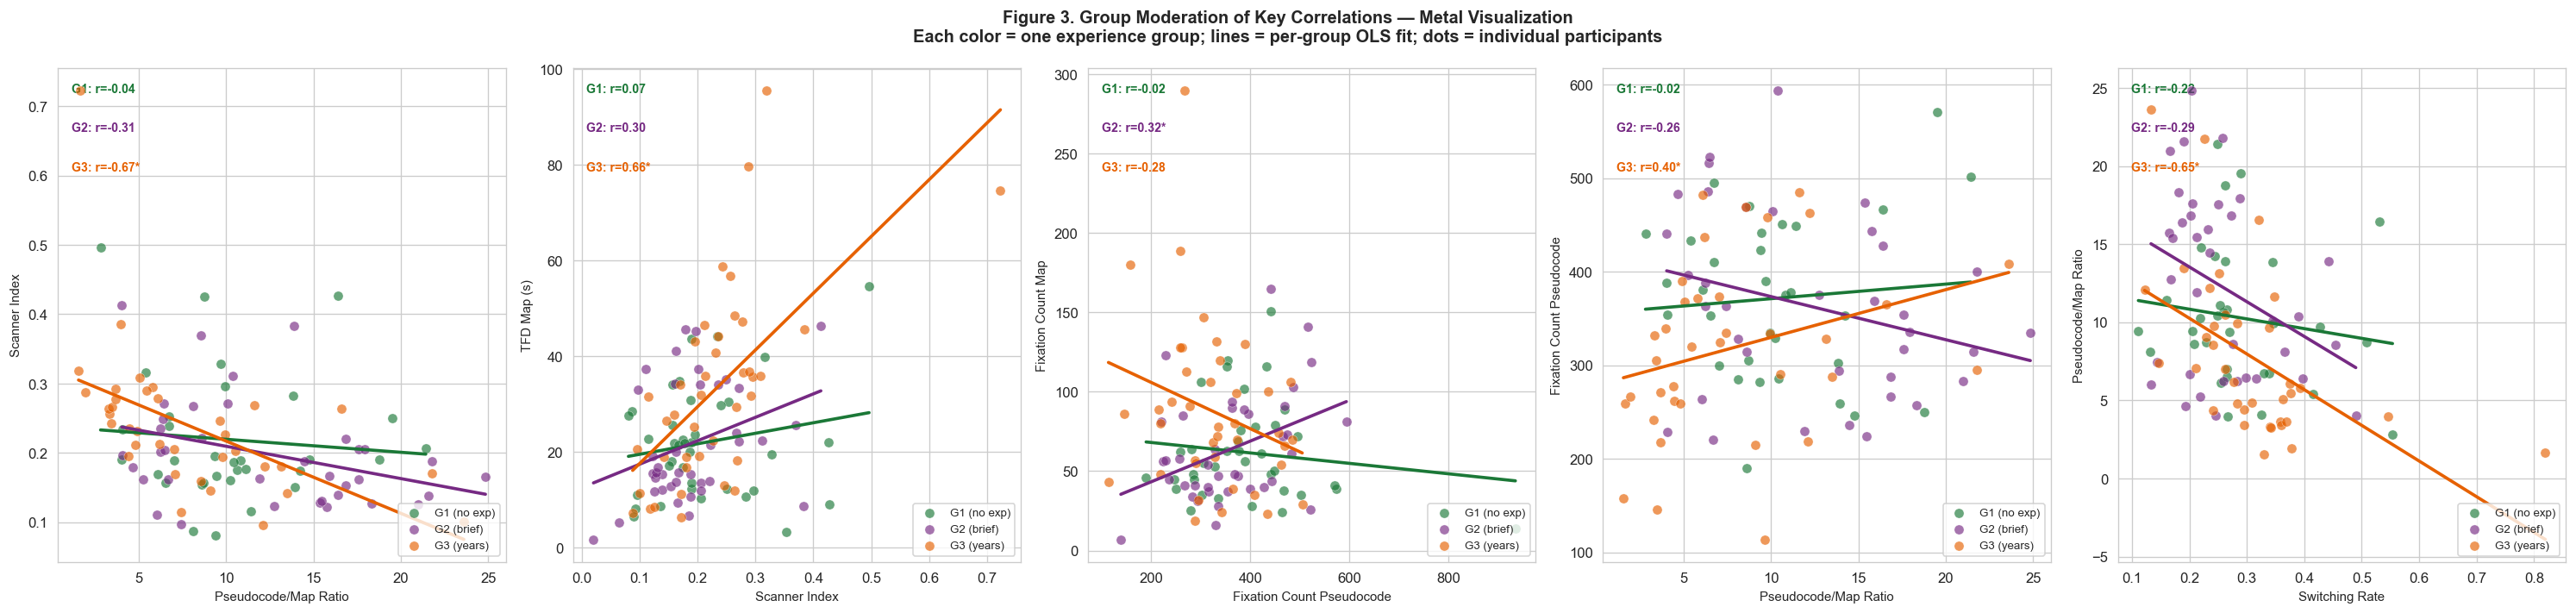

In [8]:
# Chosen from Fisher z-battery: the pairs with confirmed significance AND interpretive value
MOD_PAIRS = [
    ('ratio_c',       'scanner_index',  'Pseudocode/Map Ratio',    'Scanner Index',          'BFS+DFS'),
    ('scanner_index', 'tfd_map',        'Scanner Index',           'TFD Map (s)',             'BFS+DFS'),
    ('fc_pseudo',     'fc_map',         'Fixation Count Pseudocode','Fixation Count Map',     'BFS+DFS'),
    ('ratio_c',       'fc_pseudo',      'Pseudocode/Map Ratio',    'Fixation Count Pseudocode','BFS+DFS'),
    ('switching_rate','ratio_c',        'Switching Rate',          'Pseudocode/Map Ratio',    'BFS+DFS'),
]

fig, axes = plt.subplots(1, len(MOD_PAIRS), figsize=(5*len(MOD_PAIRS), 6))
fig.suptitle(
    'Figure 3. Group Moderation of Key Correlations — Metal Visualization\n'
    'Each color = one experience group; lines = per-group OLS fit; dots = individual participants',
    fontsize=12, fontweight='bold'
)

for ax, (x_col, y_col, x_lbl, y_lbl, subset_str) in zip(axes, MOD_PAIRS):
    sub = df.copy()
    x_all = sub[x_col].replace([np.inf,-np.inf], np.nan)
    y_all = sub[y_col].replace([np.inf,-np.inf], np.nan)

    for grp in [1, 2, 3]:
        mask = (sub['group'] == grp) & x_all.notna() & y_all.notna()
        xv = x_all[mask].values
        yv = y_all[mask].values
        if len(xv) < 3: continue

        # Scatter
        ax.scatter(xv, yv, color=GRP_COL[grp], s=45, alpha=0.65,
                   label=GRP_LBL[grp], edgecolors='white', linewidth=0.3, zorder=3)

        # Regression line
        m, b = np.polyfit(xv, yv, 1)
        xl = np.linspace(xv.min(), xv.max(), 100)
        ax.plot(xl, m*xl + b, color=GRP_COL[grp], linewidth=2.2, zorder=4)

        # Annotate Spearman r
        r, p = stats.spearmanr(xv, yv)
        ax.text(0.03, 0.97 - (grp-1)*0.08, f'G{grp}: r={r:.2f}{'*' if p<.05 else ''}',
                transform=ax.transAxes, fontsize=8.5, color=GRP_COL[grp],
                va='top', fontweight='bold')

    ax.set_xlabel(x_lbl, fontsize=9)
    ax.set_ylabel(y_lbl, fontsize=9)
    ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('fig3_moderation_scatters.png', bbox_inches='tight')
plt.show()

### Same moderation plots, broken out by algorithm (BFS vs DFS)

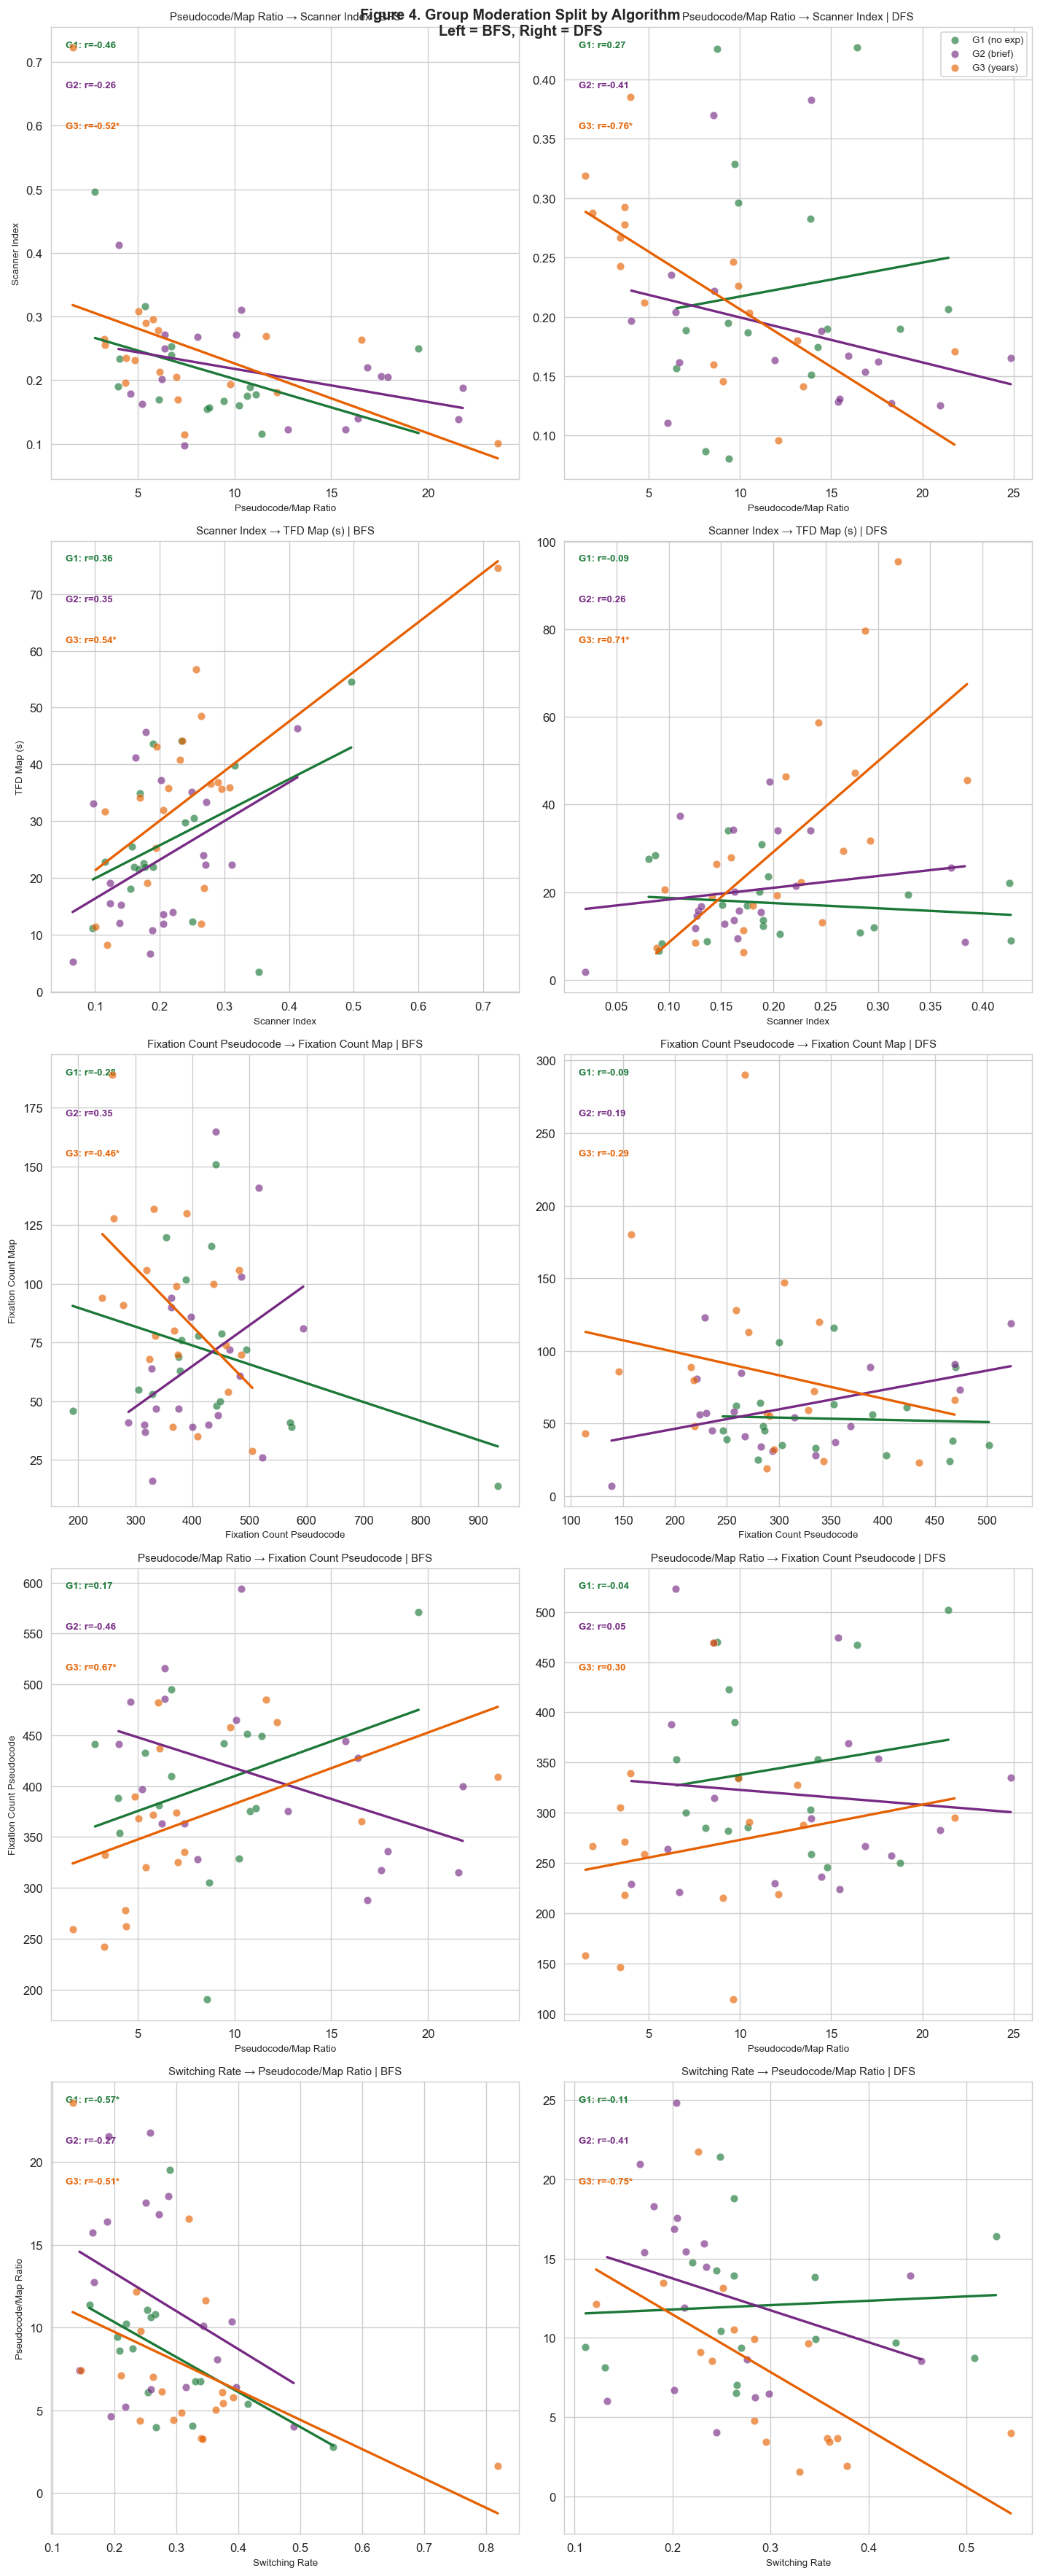

In [9]:
# 5 pairs × 2 algorithms — 10 panels in a 5×2 grid
fig, axes = plt.subplots(len(MOD_PAIRS), 2, figsize=(12, 6*len(MOD_PAIRS)))
fig.suptitle(
    'Figure 4. Group Moderation Split by Algorithm\n'
    'Left = BFS, Right = DFS',
    fontsize=12, fontweight='bold'
)

for row_idx, (x_col, y_col, x_lbl, y_lbl, _) in enumerate(MOD_PAIRS):
    for col_idx, algo in enumerate(['BFS', 'DFS']):
        ax = axes[row_idx][col_idx]
        sub = df[df['algorithm'] == algo].copy()
        x_all = sub[x_col].replace([np.inf,-np.inf], np.nan)
        y_all = sub[y_col].replace([np.inf,-np.inf], np.nan)

        for grp in [1, 2, 3]:
            mask = (sub['group'] == grp) & x_all.notna() & y_all.notna()
            xv = x_all[mask].values
            yv = y_all[mask].values
            if len(xv) < 3: continue
            ax.scatter(xv, yv, color=GRP_COL[grp], s=40, alpha=0.65,
                       label=GRP_LBL[grp], edgecolors='white', linewidth=0.3, zorder=3)
            m, b = np.polyfit(xv, yv, 1)
            xl = np.linspace(xv.min(), xv.max(), 100)
            ax.plot(xl, m*xl + b, color=GRP_COL[grp], linewidth=2, zorder=4)
            r, p = stats.spearmanr(xv, yv)
            ax.text(0.03, 0.97 - (grp-1)*0.09, f'G{grp}: r={r:.2f}{'*' if p<.05 else ''}',
                    transform=ax.transAxes, fontsize=8, color=GRP_COL[grp],
                    va='top', fontweight='bold')

        ax.set_title(f'{x_lbl} → {y_lbl} | {algo}', fontsize=9)
        ax.set_xlabel(x_lbl, fontsize=8)
        ax.set_ylabel(y_lbl if col_idx == 0 else '', fontsize=8)
        if row_idx == 0 and col_idx == 1:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig4_moderation_by_algo.png', bbox_inches='tight')
plt.show()

---
## 5. Group-Specific Predictors of Ratio

Which variables predict the pseudocode/map ratio *within each group*? A variable that predicts ratio in G1 but not G3 is a novice-specific predictor — it reflects a mechanism that is specific to inexperienced viewers. A variable that only predicts ratio in G3 reflects expert-specific processing.

In [10]:
PREDICTORS = [
    ('scanner_index',  'Scanner Index'),
    ('avg_fix_depth',  'Avg Fix Depth'),
    ('switching_rate', 'Switching Rate'),
    ('fix_before',     'Fixations Before'),
    ('ttff_pseudo',    'TTFF Pseudocode'),
    ('ttff_map',       'TTFF Map'),
    ('ffd_pseudo',     'First Fix Duration'),
    ('tfd_map',        'TFD Map'),
    ('fc_pseudo',      'FC Pseudocode'),
    ('fc_map',         'FC Map'),
    ('vc_pseudo',      'VC Pseudocode'),
    ('vc_map',         'VC Map'),
    ('map_first',      'Map First'),
]

pred_rows = []
for pred_col, pred_lbl in PREDICTORS:
    row = {'predictor': pred_lbl}
    for algo in ['BFS', 'DFS', 'ALL']:
        data = df if algo == 'ALL' else df[df['algorithm'] == algo]
        for grp in [1, 2, 3]:
            sub = data[data['group'] == grp]
            x = sub[pred_col].replace([np.inf,-np.inf], np.nan)
            y = sub['ratio_c'].replace([np.inf,-np.inf], np.nan)
            valid = x.notna() & y.notna()
            if valid.sum() < 4:
                row[f'{algo}_G{grp}_r'] = np.nan
                row[f'{algo}_G{grp}_p'] = np.nan
            else:
                r, p = stats.spearmanr(x[valid], y[valid])
                row[f'{algo}_G{grp}_r'] = round(r, 3)
                row[f'{algo}_G{grp}_p'] = round(p, 4)
    pred_rows.append(row)

pred_df = pd.DataFrame(pred_rows).set_index('predictor')

# Show ALL (combined algorithm) columns for readability
all_cols_r = [f'ALL_G{g}_r' for g in [1,2,3]]
all_cols_p = [f'ALL_G{g}_p' for g in [1,2,3]]
display = pred_df[all_cols_r].copy()
display.columns = ['G1 r', 'G2 r', 'G3 r']

# Add significance markers
for g in [1,2,3]:
    display[f'G{g} sig'] = pred_df[f'ALL_G{g}_p'].apply(sig)

print('=== Predictors of Pseudocode/Map Ratio, within each Group (Spearman, all algorithms) ===')
print(display.to_string())

=== Predictors of Pseudocode/Map Ratio, within each Group (Spearman, all algorithms) ===
                     G1 r   G2 r   G3 r G1 sig G2 sig G3 sig
predictor                                                   
Scanner Index      -0.037 -0.313 -0.674     ns      ~    ***
Avg Fix Depth       0.153  0.410  0.133     ns      *     ns
Switching Rate     -0.223 -0.294 -0.647     ns      ~    ***
Fixations Before    0.309 -0.120  0.020      ~     ns     ns
TTFF Pseudocode     0.298  0.033 -0.132      ~     ns     ns
TTFF Map            0.240  0.092  0.029     ns     ns     ns
First Fix Duration  0.179 -0.023 -0.069     ns     ns     ns
TFD Map            -0.893 -0.949 -0.928    ***    ***    ***
FC Pseudocode      -0.018 -0.256  0.401     ns     ns      *
FC Map             -0.737 -0.846 -0.881    ***    ***    ***
VC Pseudocode       0.112 -0.211 -0.293     ns     ns      ~
VC Map             -0.572 -0.393 -0.754    ***      *    ***
Map First           0.225 -0.115 -0.030     ns     ns    

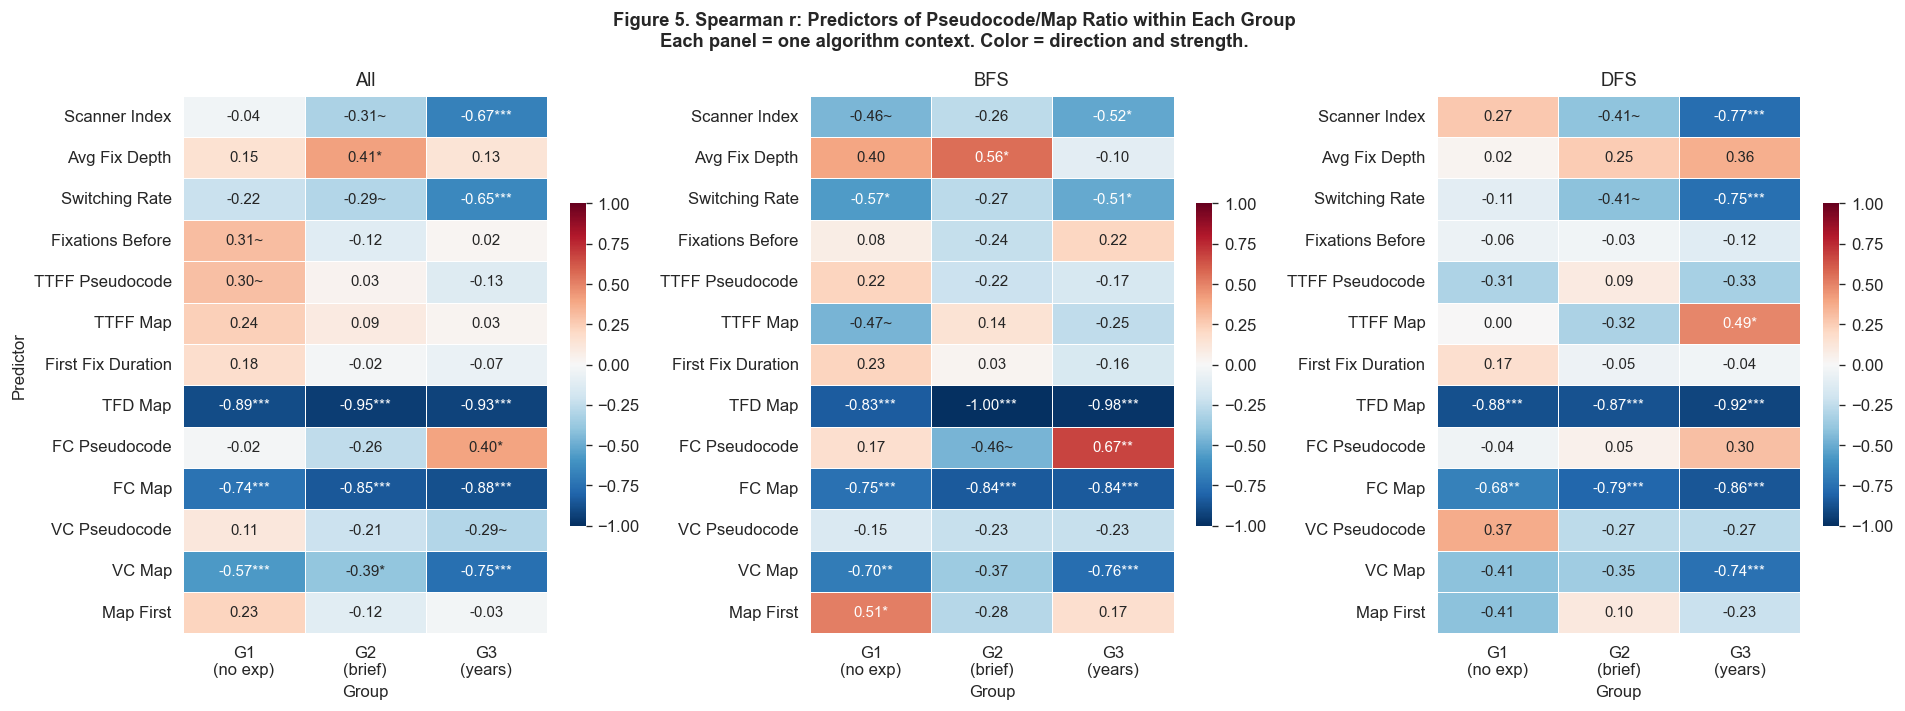

In [11]:
# Figure 5 — Heatmap: predictor × group r values for ALL, BFS, DFS
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle(
    'Figure 5. Spearman r: Predictors of Pseudocode/Map Ratio within Each Group\n'
    'Each panel = one algorithm context. Color = direction and strength.',
    fontsize=11, fontweight='bold'
)

for ax, algo in zip(axes, ['ALL', 'BFS', 'DFS']):
    r_data = pred_df[[f'{algo}_G{g}_r' for g in [1,2,3]]].copy()
    p_data = pred_df[[f'{algo}_G{g}_p' for g in [1,2,3]]].copy()
    r_data.columns = ['G1\n(no exp)', 'G2\n(brief)', 'G3\n(years)']
    p_data.columns = r_data.columns

    # Annotation: r + sig marker
    annot = r_data.copy().astype(object)
    for col in r_data.columns:
        for idx in r_data.index:
            rv = r_data.loc[idx, col]
            pv = p_data.loc[idx, col]
            if pd.isna(rv):
                annot.loc[idx, col] = ''
            else:
                mk = '***' if pv<.001 else '**' if pv<.01 else '*' if pv<.05 else '~' if pv<.10 else ''
                annot.loc[idx, col] = f'{rv:.2f}{mk}'

    sns.heatmap(
        r_data.astype(float), annot=annot, fmt='',
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        linewidths=0.4, ax=ax, cbar_kws={'shrink': 0.6},
        annot_kws={'size': 9}
    )
    ax.set_title(f'{"All" if algo=="ALL" else algo}', fontsize=11)
    ax.set_xlabel('Group')
    ax.set_ylabel('Predictor' if algo == 'ALL' else '')

plt.tight_layout()
plt.savefig('fig5_ratio_predictors_by_group.png', bbox_inches='tight')
plt.show()

---
## 6. Dual-Engagement vs Trade-Off: The G2 Anomaly

The Fisher z-test flagged `fc_pseudo ↔ fc_map` as one of the most group-moderated pairs. In G2, this correlation is *positive* — intermediates who make many fixations on pseudocode also make many fixations on the map. In G1 and G3, the relationship is negative (zero-sum).

This section tests whether this reversal is robust across both algorithms, and whether it generalizes to visit counts and total fixation durations.

In [12]:
ENGAGEMENT_PAIRS = [
    ('fc_pseudo',   'fc_map',   'Fixation Count Pseudo', 'Fixation Count Map'),
    ('vc_pseudo',   'vc_map',   'Visit Count Pseudo',    'Visit Count Map'),
    ('tfd_pseudo',  'tfd_map',  'TFD Pseudo (s)',        'TFD Map (s)'),
]

print('=== Dual-Engagement vs Trade-Off: Spearman r per Group × Algorithm ===')
print(f'{"Pair":<35} {"G1 BFS":>8} {"G1 DFS":>8} {"G2 BFS":>8} {"G2 DFS":>8} {"G3 BFS":>8} {"G3 DFS":>8}')
print('-' * 90)

for x_col, y_col, x_lbl, y_lbl in ENGAGEMENT_PAIRS:
    label = f'{x_lbl} ↔ {y_lbl}'
    vals = []
    for algo in ['BFS', 'DFS']:
        for grp in [1, 2, 3]:
            sub = df[(df['group']==grp) & (df['algorithm']==algo)]
            x = sub[x_col].replace([np.inf,-np.inf],np.nan)
            y = sub[y_col].replace([np.inf,-np.inf],np.nan)
            valid = x.notna() & y.notna()
            if valid.sum() < 4:
                vals.append(f'   —  ')
            else:
                r, p = stats.spearmanr(x[valid], y[valid])
                mk = '*' if p<.05 else '~' if p<.10 else ' '
                vals.append(f'{r:+.2f}{mk} ')
    # reorder to G1BFS, G1DFS, G2BFS, G2DFS, G3BFS, G3DFS
    reordered = [vals[0],vals[3],vals[1],vals[4],vals[2],vals[5]]
    print(f'{label:<35}' + ''.join(f'{v:>9}' for v in reordered))

=== Dual-Engagement vs Trade-Off: Spearman r per Group × Algorithm ===
Pair                                  G1 BFS   G1 DFS   G2 BFS   G2 DFS   G3 BFS   G3 DFS
------------------------------------------------------------------------------------------
Fixation Count Pseudo ↔ Fixation Count Map  -0.28    -0.09    +0.35    +0.19    -0.46*   -0.29  
Visit Count Pseudo ↔ Visit Count Map  +0.43~   +0.49*   +0.73*   +0.53*   +0.73*   +0.68* 
TFD Pseudo (s) ↔ TFD Map (s)         -0.57*   -0.11    -0.63*   -0.37    -0.79*   -0.66* 


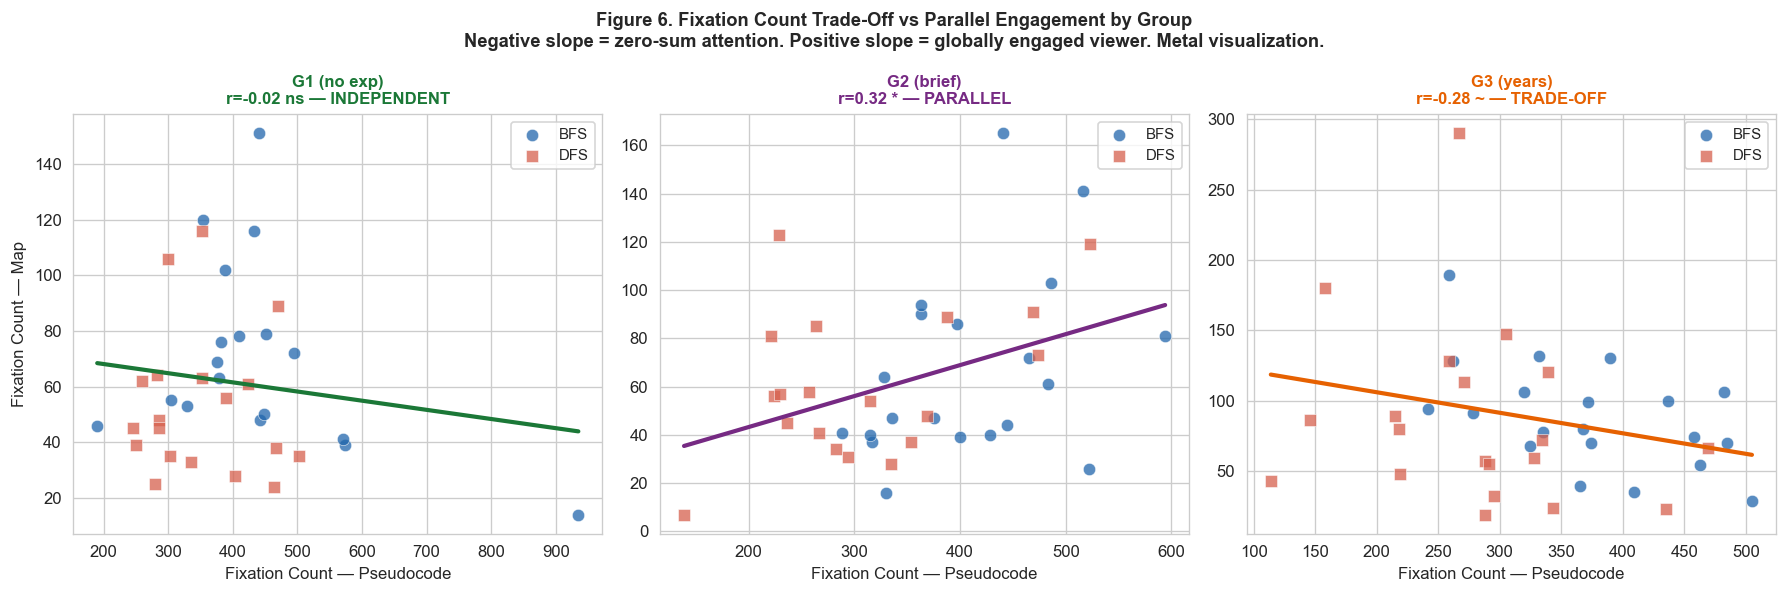

In [13]:
# Figure 6 — FC pseudo vs FC map for all three groups, scatter with regression
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    'Figure 6. Fixation Count Trade-Off vs Parallel Engagement by Group\n'
    'Negative slope = zero-sum attention. Positive slope = globally engaged viewer. Metal visualization.',
    fontsize=11, fontweight='bold'
)

for ax, grp in zip(axes, [1, 2, 3]):
    sub = df[df['group'] == grp].dropna(subset=['fc_pseudo', 'fc_map'])
    bfs_m = sub[sub['algorithm']=='BFS']
    dfs_m = sub[sub['algorithm']=='DFS']

    for algo_df, algo, mk in [(bfs_m, 'BFS', 'o'), (dfs_m, 'DFS', 's')]:
        ax.scatter(algo_df['fc_pseudo'], algo_df['fc_map'],
                   color=ALG_PAL[algo], marker=mk, s=55, alpha=0.75,
                   label=algo, edgecolors='white', linewidth=0.4)

    # Overall regression for this group
    xv, yv = sub['fc_pseudo'].values, sub['fc_map'].values
    m_slope, b = np.polyfit(xv, yv, 1)
    xl = np.linspace(xv.min(), xv.max(), 100)
    ax.plot(xl, m_slope*xl + b, color=GRP_COL[grp], linewidth=2.5, zorder=5)

    r, p = stats.spearmanr(xv, yv)
    sig_mk = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else '~' if p<.10 else 'ns'
    pattern = 'PARALLEL' if r > 0.1 else 'TRADE-OFF' if r < -0.1 else 'INDEPENDENT'

    ax.set_title(f'{GRP_LBL[grp]}\nr={r:.2f} {sig_mk} — {pattern}', fontsize=10,
                 color=GRP_COL[grp], fontweight='bold')
    ax.set_xlabel('Fixation Count — Pseudocode', fontsize=10)
    ax.set_ylabel('Fixation Count — Map' if grp == 1 else '', fontsize=10)
    ax.legend(fontsize=9)
    ax.axhline(ax.get_ylim()[0] if ax.get_ylim() else 0, color='#ccc', linewidth=0.5)

plt.tight_layout()
plt.savefig('fig6_dual_engagement.png', bbox_inches='tight')
plt.show()

---
## 7. Partial Correlations: Separating Group and Algorithm Effects

Two confounds could inflate or deflate metric-metric correlations:
1. **Group**: participants from the same group share similar gaze patterns by virtue of their experience level, not because of the actual relationship between metrics
2. **Algorithm**: BFS and DFS produce systematically different TTFF, fix_before, etc. — this can create spurious correlations between metrics that simply reflect algorithm assignment

Partial Spearman correlations remove these effects, leaving only the within-group, within-algorithm relationship.

In [14]:
def partial_spearman(data, x_col, y_col, control_cols):
    """
    Partial Spearman correlation between x and y, controlling for control_cols.
    Method: rank all variables, then regress x-ranks on control-ranks,
    regress y-ranks on control-ranks, correlate residuals.
    """
    sub = data[[x_col, y_col] + control_cols].replace([np.inf,-np.inf],np.nan).dropna()
    if len(sub) < 6:
        return np.nan, np.nan, len(sub)

    # Convert all to ranks
    ranked = sub.rank()

    # Regress x on controls, get residual
    X_ctrl = ranked[control_cols].values
    X_ctrl = np.column_stack([np.ones(len(X_ctrl)), X_ctrl])
    rx = ranked[x_col].values
    ry = ranked[y_col].values
    bx, *_ = np.linalg.lstsq(X_ctrl, rx, rcond=None)
    by, *_ = np.linalg.lstsq(X_ctrl, ry, rcond=None)
    res_x = rx - X_ctrl @ bx
    res_y = ry - X_ctrl @ by

    r, p = stats.pearsonr(res_x, res_y)
    return r, p, len(sub)


# Encode categorical controls as numbers
df['algo_num'] = df['algorithm'].map({'BFS': 0, 'DFS': 1})

PARTIAL_PAIRS = [
    ('ratio_c',       'scanner_index'),
    ('ratio_c',       'fc_pseudo'),
    ('ratio_c',       'switching_rate'),
    ('fc_pseudo',     'fc_map'),
    ('scanner_index', 'tfd_map'),
    ('avg_fix_depth', 'switching_rate'),
    ('fix_before',    'ratio_c'),
    ('ttff_pseudo',   'avg_fix_depth'),
    ('tfd_pseudo',    'tfd_map'),
]

print('=== Raw vs Partial Spearman Correlations ===')
print('Partial: controlling for (1) group only, (2) algorithm only, (3) both')
print()
print(f'{"Pair":<38} {"Raw r":>7} {"Ctrl Group":>11} {"Ctrl Algo":>10} {"Ctrl Both":>10}')
print('-' * 80)

for x_col, y_col in PARTIAL_PAIRS:
    x_v = df[x_col].replace([np.inf,-np.inf],np.nan)
    y_v = df[y_col].replace([np.inf,-np.inf],np.nan)
    valid = x_v.notna() & y_v.notna()
    r_raw, _ = stats.spearmanr(x_v[valid], y_v[valid])

    r_g, pg, _ = partial_spearman(df, x_col, y_col, ['group'])
    r_a, pa, _ = partial_spearman(df, x_col, y_col, ['algo_num'])
    r_b, pb, _ = partial_spearman(df, x_col, y_col, ['group', 'algo_num'])

    def fmt_r(r, p):
        if np.isnan(r): return '  —    '
        mk = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else '~' if p<.10 else ''
        return f'{r:+.3f}{mk:<3}'

    label = f'{x_col}  ↔  {y_col}'
    print(f'{label:<38} {r_raw:+.3f}  {fmt_r(r_g,pg):>11} {fmt_r(r_a,pa):>10} {fmt_r(r_b,pb):>10}')

=== Raw vs Partial Spearman Correlations ===
Partial: controlling for (1) group only, (2) algorithm only, (3) both

Pair                                     Raw r  Ctrl Group  Ctrl Algo  Ctrl Both
--------------------------------------------------------------------------------
ratio_c  ↔  scanner_index              -0.439    -0.420***  -0.432***  -0.414***
ratio_c  ↔  fc_pseudo                  +0.068    +0.013     +0.158     +0.099   
ratio_c  ↔  switching_rate             -0.456    -0.450***  -0.451***  -0.444***
fc_pseudo  ↔  fc_map                   -0.018    +0.034     -0.103     -0.048   
scanner_index  ↔  tfd_map              +0.399    +0.385***  +0.384***  +0.369***
avg_fix_depth  ↔  switching_rate       -0.533    -0.555***  -0.532***  -0.558***
fix_before  ↔  ratio_c                 +0.046    +0.056     -0.091     -0.077   
ttff_pseudo  ↔  avg_fix_depth          +0.274    +0.282**   -0.093     -0.090   
tfd_pseudo  ↔  tfd_map                 -0.524    -0.525***  -0.536***  -0.

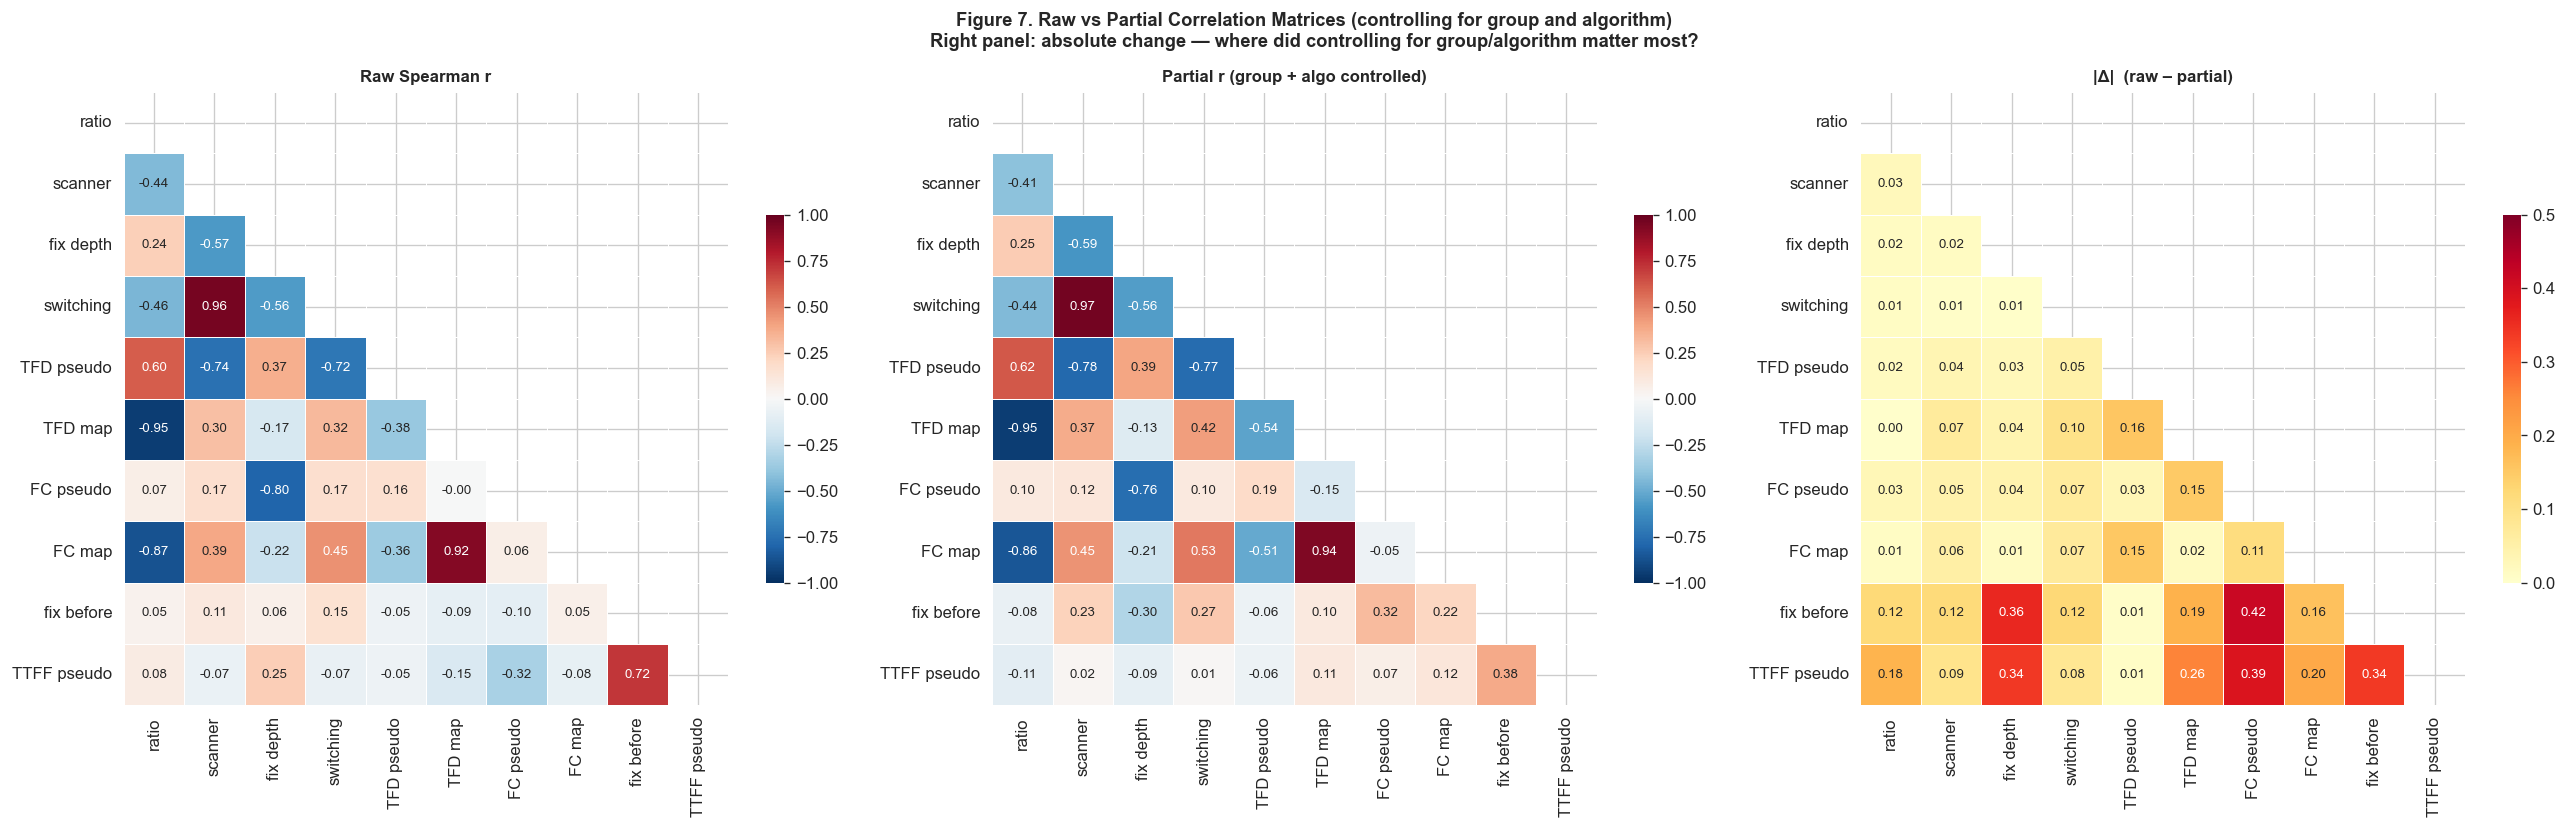

In [15]:
# Figure 7 — Side-by-side correlation matrices: raw vs partial (controlling both group and algorithm)

MATRIX_METRICS = [
    'ratio_c', 'scanner_index', 'avg_fix_depth', 'switching_rate',
    'tfd_pseudo', 'tfd_map', 'fc_pseudo', 'fc_map', 'fix_before', 'ttff_pseudo'
]
MATRIX_LBL = [
    'ratio', 'scanner', 'fix depth', 'switching',
    'TFD pseudo', 'TFD map', 'FC pseudo', 'FC map', 'fix before', 'TTFF pseudo'
]

# Raw correlation matrix
sub_raw = df[MATRIX_METRICS].replace([np.inf,-np.inf],np.nan).dropna()
corr_raw = sub_raw.corr(method='spearman')
corr_raw.index = MATRIX_LBL; corr_raw.columns = MATRIX_LBL

# Partial correlation matrix (controlling for group and algorithm)
n = len(MATRIX_METRICS)
partial_mat = pd.DataFrame(np.zeros((n, n)), index=MATRIX_LBL, columns=MATRIX_LBL)
for i in range(n):
    for j in range(n):
        if i == j:
            partial_mat.iloc[i,j] = 1.0
        else:
            r, _, _ = partial_spearman(df, MATRIX_METRICS[i], MATRIX_METRICS[j],
                                       ['group', 'algo_num'])
            partial_mat.iloc[i,j] = r if not np.isnan(r) else 0

delta_partial = (partial_mat - corr_raw).abs()

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(
    'Figure 7. Raw vs Partial Correlation Matrices (controlling for group and algorithm)\n'
    'Right panel: absolute change — where did controlling for group/algorithm matter most?',
    fontsize=11, fontweight='bold'
)

mask = np.triu(np.ones((n,n), dtype=bool))

for ax, mat, title in [
    (axes[0], corr_raw,     'Raw Spearman r'),
    (axes[1], partial_mat,  'Partial r (group + algo controlled)'),
    (axes[2], delta_partial,'|Δ|  (raw – partial)'),
]:
    cmap = 'RdBu_r' if 'Δ' not in title else 'YlOrRd'
    center = 0 if 'Δ' not in title else None
    vmin = -1 if 'Δ' not in title else 0
    vmax = 1 if 'Δ' not in title else 0.5
    sns.heatmap(
        mat, mask=mask, annot=True, fmt='.2f',
        cmap=cmap, center=center, vmin=vmin, vmax=vmax,
        linewidths=0.4, ax=ax, cbar_kws={'shrink': 0.6},
        annot_kws={'size': 8}
    )
    ax.set_title(title, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig7_partial_corr_matrix.png', bbox_inches='tight')
plt.show()

---
## 8. The Coupling Hypothesis: Does Expertise Tighten the Attentional System?

The most consistent pattern in the Fisher z-battery is that many correlations are *stronger* in G3 than in G1. This suggests that expertise doesn't just shift attention levels — it creates tighter coupling between gaze behaviors. Metrics that are independent in novices become predictive of each other in experts.

We test this directly: compute the mean absolute correlation across all metric pairs, separately for each group. If G3 shows systematically higher mean |r|, the attentional system is more tightly organized in experienced viewers.

In [16]:
COUPLING_METRICS = [
    'ratio_c', 'scanner_index', 'avg_fix_depth', 'switching_rate',
    'tfd_pseudo', 'tfd_map', 'fc_pseudo', 'fc_map',
    'vc_pseudo', 'vc_map', 'fix_before', 'ttff_pseudo', 'ffd_pseudo'
]

print('=== Mean |Spearman r| across all metric pairs, by group and algorithm ===')
print('Higher = more tightly coupled attentional system')
print()

coupling_rows = []
for grp in [1, 2, 3]:
    for algo in ['BFS', 'DFS', 'ALL']:
        sub = df if algo=='ALL' else df[df['algorithm']==algo]
        sub = sub[sub['group']==grp]
        data = sub[COUPLING_METRICS].replace([np.inf,-np.inf],np.nan).dropna()
        if len(data) < 5: continue
        corr = data.corr(method='spearman')
        # Extract lower triangle (exclude diagonal)
        lower = corr.values[np.tril_indices(len(COUPLING_METRICS), k=-1)]
        mean_abs_r = np.mean(np.abs(lower))
        coupling_rows.append({'group': grp, 'algo': algo, 'mean_abs_r': round(mean_abs_r, 4),
                               'n_metrics': len(COUPLING_METRICS), 'n_pairs': len(lower)})
        print(f'  G{grp} {algo:<4}: mean |r| = {mean_abs_r:.4f}  (n={len(data)} participants, {len(lower)} pairs)')

coupling_df = pd.DataFrame(coupling_rows)

=== Mean |Spearman r| across all metric pairs, by group and algorithm ===
Higher = more tightly coupled attentional system

  G1 BFS : mean |r| = 0.4019  (n=16 participants, 78 pairs)
  G1 DFS : mean |r| = 0.3357  (n=16 participants, 78 pairs)
  G1 ALL : mean |r| = 0.2941  (n=32 participants, 78 pairs)
  G2 BFS : mean |r| = 0.4161  (n=18 participants, 78 pairs)
  G2 DFS : mean |r| = 0.3279  (n=18 participants, 78 pairs)
  G2 ALL : mean |r| = 0.3300  (n=36 participants, 78 pairs)
  G3 BFS : mean |r| = 0.3967  (n=19 participants, 78 pairs)
  G3 DFS : mean |r| = 0.3733  (n=17 participants, 78 pairs)
  G3 ALL : mean |r| = 0.3693  (n=36 participants, 78 pairs)


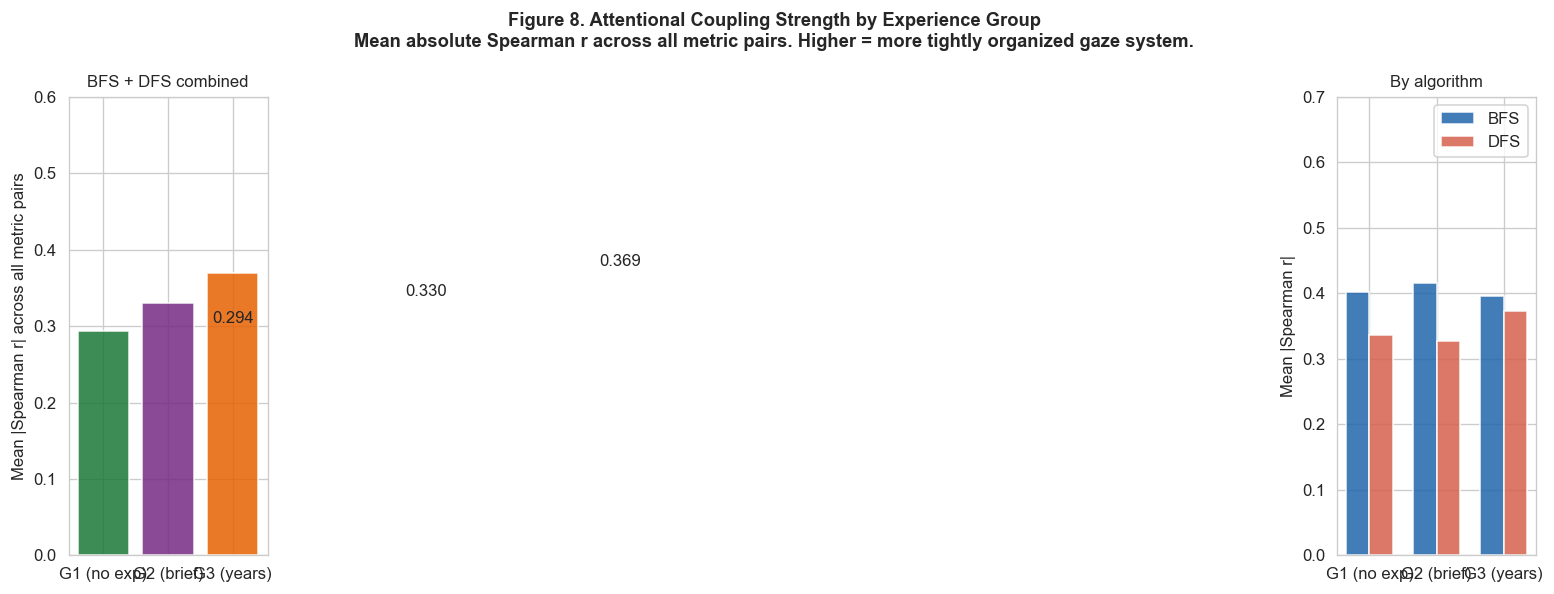

In [17]:
# Figure 8 — Coupling strength by group × algorithm
all_coupling = coupling_df[coupling_df['algo']=='ALL']
bfs_coupling = coupling_df[coupling_df['algo']=='BFS']
dfs_coupling = coupling_df[coupling_df['algo']=='DFS']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'Figure 8. Attentional Coupling Strength by Experience Group\n'
    'Mean absolute Spearman r across all metric pairs. Higher = more tightly organized gaze system.',
    fontsize=11, fontweight='bold'
)

# Left: all algorithms combined
ax = axes[0]
ax.bar([GRP_LBL[g] for g in [1,2,3]],
       all_coupling.sort_values('group')['mean_abs_r'],
       color=[GRP_COL[g] for g in [1,2,3]], alpha=0.85, edgecolor='white')
ax.set_title('BFS + DFS combined', fontsize=10)
ax.set_ylabel('Mean |Spearman r| across all metric pairs')
ax.set_ylim(0, 0.6)
for g, row in all_coupling.sort_values('group').iterrows():
    ax.text(g, row['mean_abs_r'] + 0.01, f"{row['mean_abs_r']:.3f}", ha='center', fontsize=10)

# Right: BFS vs DFS per group
ax = axes[1]
x = np.array([1, 2, 3])
w = 0.35
bfs_vals = bfs_coupling.sort_values('group')['mean_abs_r'].values
dfs_vals = dfs_coupling.sort_values('group')['mean_abs_r'].values
ax.bar(x - w/2, bfs_vals, w, color=ALG_PAL['BFS'], alpha=0.85, label='BFS')
ax.bar(x + w/2, dfs_vals, w, color=ALG_PAL['DFS'], alpha=0.85, label='DFS')
ax.set_xticks(x)
ax.set_xticklabels([GRP_LBL[g] for g in [1,2,3]])
ax.set_ylabel('Mean |Spearman r|')
ax.set_title('By algorithm', fontsize=10)
ax.set_ylim(0, 0.7)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig8_coupling_strength.png', bbox_inches='tight')
plt.show()

---
## 9. Summary: What Changes Across Groups?

A consolidated table of all significant Fisher z-test results, organized by the type of change observed.

In [18]:
# Classify each significant pair by its pattern
sig_bat = bat[bat['min_p'] < 0.05].copy()

def classify(row):
    r1, r2, r3 = row['r_G1'], row['r_G2'], row['r_G3']
    if r1 * r3 < 0:
        return 'REVERSAL (G1↔G3 sign change)'
    if abs(r3) > abs(r1) + 0.2:
        return 'STRENGTHENS with expertise'
    if abs(r1) > abs(r3) + 0.2:
        return 'DISSOLVES with expertise'
    if abs(r2) < abs(r1) - 0.15 and abs(r2) < abs(r3) - 0.15:
        return 'MINIMUM at G2 (U-shape)'
    if abs(r2) > abs(r1) + 0.15 and abs(r2) > abs(r3) + 0.15:
        return 'MAXIMUM at G2 (inverted-U)'
    return 'OTHER difference'

sig_bat['pattern'] = sig_bat.apply(classify, axis=1)
sig_bat_sorted = sig_bat.sort_values(['pattern', 'min_p'])

print(f'=== Significant Group-Moderated Correlations (Fisher z p<.05) — n={len(sig_bat)} pairs ===')
print()
for pattern, group in sig_bat_sorted.groupby('pattern', sort=False):
    print(f'\n  [{pattern}]')
    for _, r in group.iterrows():
        print(f'  {r["x"]:20} ↔ {r["y"]:20}  '
              f'G1={r["r_G1"]:+.2f}  G2={r["r_G2"]:+.2f}  G3={r["r_G3"]:+.2f}  '
              f'(min_p={r["min_p"]:.4f})')

=== Significant Group-Moderated Correlations (Fisher z p<.05) — n=27 pairs ===


  [MAXIMUM at G2 (inverted-U)]
  fc_pseudo            ↔ vc_map                G1=-0.01  G2=+0.34  G3=-0.14  (min_p=0.0373)

  [MINIMUM at G2 (U-shape)]
  tfd_map              ↔ vc_map                G1=+0.76  G2=+0.58  G3=+0.86  (min_p=0.0090)
  ratio_c              ↔ vc_map                G1=-0.57  G2=-0.39  G3=-0.75  (min_p=0.0215)

  [OTHER difference]
  scanner_index        ↔ vc_pseudo             G1=+0.88  G2=+0.95  G3=+0.73  (min_p=0.0001)
  switching_rate       ↔ vc_pseudo             G1=+0.83  G2=+0.94  G3=+0.71  (min_p=0.0006)
  fc_map               ↔ vc_map                G1=+0.88  G2=+0.74  G3=+0.90  (min_p=0.0278)
  avg_fix_depth        ↔ fc_pseudo             G1=-0.82  G2=-0.87  G3=-0.68  (min_p=0.0288)
  scanner_index        ↔ switching_rate        G1=+0.93  G2=+0.97  G3=+0.97  (min_p=0.0319)

  [REVERSAL (G1↔G3 sign change)]
  ratio_c              ↔ fc_pseudo             G1=-0.02  G2=-0.26  

---
## 10. Interpretation Guide

### Ratio ↔ Scanner Index: Expertise Creates Coupling

In G1, the correlation between a viewer's scanning behavior on pseudocode and their overall code/map ratio is near zero — novices who scan rapidly and novices who deep-read end up with similar ratios. In G3, this correlation is strongly negative (r ≈ –0.67): experts who scan more also spend proportionally less time on pseudocode relative to the map.

**What this means:** For novices, *how* they look at pseudocode is disconnected from *how much* they look at it. For experts, these are tightly coupled — a fast-scanning expert is efficient and can afford to look at the map more, while a deep-reading expert is working through unfamiliar code and stays on it longer. Expertise doesn't just change the level of any single metric; it creates a meaningful *relationship* between metrics that wasn't there before.

**Implication:** You cannot use scanner index as a proxy for engagement level in novice audiences. It's a meaningful predictor only once viewers have enough background knowledge to modulate their fixation depth purposefully.

---

### FC Pseudo ↔ FC Map: The G2 Anomaly

In G1 and G3, fixation counts on pseudocode and the map are negatively correlated — viewers are trading one for the other (zero-sum attention). In G2, the relationship is positive: intermediates who look at the code a lot also look at the map a lot. They have the same total attentional budget as everyone else, but they're not trading it off between panels — they're making more fixations overall.

**What this means:** G2 intermediates are actively integrating both representations. They are neither map-watchers who ignore code nor code-readers who ignore the map — they are alternating between both. This is exactly the active dual-process that algorithm visualization is theoretically supposed to induce. G1 viewers haven't yet formed enough of a schema to use the map productively while reading code. G3 viewers already have schemas strong enough that they don't need to consult both — they read code or watch the graph, not both at once.

**Implication:** If the research goal is to promote active integration of pseudocode and visual graph, Group 2 is the target audience. The animation is accomplishing its integrative purpose specifically for this group. G1 needs scaffolding to enable integration; G3 doesn't need it.

---

### Scanner Index ↔ TFD Map: Experts Who Scan Code Watch the Graph More

In G1, no meaningful relationship between scanning behavior on pseudocode and time spent on the map. In G3, strongly positive (r ≈ +0.66): experts who make many brief code checks also spend more time on the map.

**What this means:** Expert scanning is a form of efficient code processing — a quick glance confirms what they already expected. The time saved by not deep-reading pseudocode is reallocated to watching the graph. This is purposeful reallocation, not distraction. For novices, there's no such purposeful reallocation — scanning doesn't free up any attention because it doesn't accomplish the comprehension work.

---

### Coupling Strength (Section 8)

If the mean absolute correlation increases monotonically from G1 → G2 → G3, it confirms the coupling hypothesis: expertise doesn't just shift metric *means*, it reorganizes the metric *covariance structure*. The attentional system becomes more coherent — individual metrics become more predictive of each other — as viewers develop greater programming knowledge.

This has methodological implications: eye-tracking studies of algorithm comprehension that do not account for experience level may be pooling participants whose attention is organized by fundamentally different mechanisms.

---

### Partial Correlations (Section 7)

Pairs where the partial r (controlling for group and algorithm) differs substantially from the raw r were inflated by group or algorithm composition. These relationships were not really about how the two metrics co-vary — they were artifacts of the group-level or algorithm-level mean differences. Pairs where partial r ≈ raw r represent genuine within-participant relationships that exist regardless of experience level or algorithm.

---

## 11. Limitations

1. **Multiple comparisons.** The Fisher z-test battery tests ~100 pairs; some significant results are expected by chance. Treat p < .01 results as more reliable; p < .05 as directional.
2. **Small n per cell.** G1/G2/G3 have ~38–40 participants each (combined BFS+DFS). Fisher z-tests are underpowered for small true differences.
3. **Groups are not randomized.** Experience level is a pre-existing trait, not an experimental manipulation. Observed differences may reflect selection factors beyond programming experience.
4. **Partial correlation method.** The rank-regression approach approximates partial Spearman correlation; it is not exact, particularly when control variables have nonlinear relationships with the outcome.
5. **Metal only.** All results condition on the Metal visualization style.